<a href="https://colab.research.google.com/github/Adyypower/Deep-learning-Models-or-topics/blob/main/localization__model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
try:
  %tensorflow_version 2.x
except Exception:
  pass

import tensorflow as tf
print(tf.__version__)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
2.19.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam,SGD

In [4]:
vgg = tf.keras.applications.VGG16(
    input_shape = [100,100,3],include_top = False,weights = 'imagenet'
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [5]:
x = Flatten()(vgg.output)
x = Dense(4,activation = 'sigmoid')(x)
model = Model(vgg.input,x)

In [10]:
def image_generator(batch_size = 64):
  while True:
    for _ in range(batch_size):
      x = np.zeros((batch_size,100,100,3))
      y = np.zeros((batch_size,4))

      for i in range(batch_size):
        row0 = np.random.randint(0,90)
        col0 = np.random.randint(0,90)
        row1 = np.random.randint(row0,100)
        col1 = np.random.randint(col0,100)
        x[i,row0:row1,col0:col1,:] = 1
        y[i,0] = row0/100.
        y[i,1] = col0/100.
        y[i,2] = (row1 - row0)/100.
        y[i,3] = (col1 - col0)/100
      yield x,y

In [7]:
model.compile(loss = 'binary_crossentropy',optimizer = Adam(learning_rate = 0.001))

In [12]:
model.fit(image_generator(),steps_per_epoch = 50,epochs = 5)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - loss: 0.7275
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - loss: 0.5223
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 222ms/step - loss: 0.5124
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 223ms/step - loss: 0.5074
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 223ms/step - loss: 0.5106


In [24]:
from matplotlib.patches import Rectangle
def make_prediction():
  x = np.zeros((100,100,3))
  row0 = np.random.randint(90)
  col0 = np.random.randint(90)
  row1 = np.random.randint(row0,100)
  col1 = np.random.randint(col0,100)
  x[row0:row1,col0:col1,:] = 1

  # predict
  x_expend = np.expand_dims(x,0)
  p = model.predict(x_expend)[0]

  # Draw the box

  fig,ax = plt.subplots(1)
  ax.imshow(x)
  rect = Rectangle(
      (p[1]*100,p[0]*100),
       p[3]*100 , p[2]*100,linewidth = 1,edgecolor = 'r',facecolor = 'none')

  ax.add_patch(rect)
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


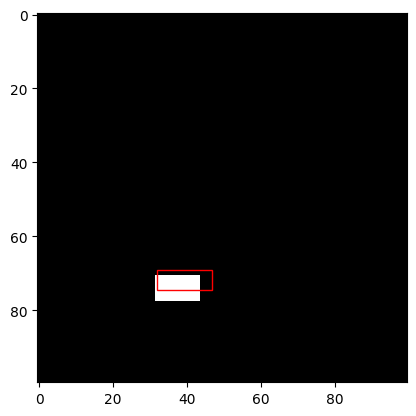

In [30]:
make_prediction()